# Witvliet connectomes

Eight developmental chemical connectomes are compared through graph structure, pooled degrees, and frequency-dependent neighbours.

All developmental stages share one node layout and plotting scale.

In [1]:
import importlib
from contextlib import redirect_stdout
from io import StringIO
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from scipy.stats import lognorm

In [2]:
DATA_DIR = Path("data")
FIGURE_DIR = Path("figures") / "witvliet"

DATASET_NUMBERS = range(1, 9)
STAGES = ["L1", "L1", "L1", "L1", "L2", "L3", "Adult", "Adult"]

EDGE_QUANTILE = 0.90
LAYOUT_SEED = 42

SPECTRAL_QUANTILES = [0.10, 0.50, 0.90]
ETA_FRACTION = 0.05
NEIGHBOUR_COUNT = 3

CMAP = "plasma"
DATA_COLOUR = "#0072B2"
FIT_COLOUR = "#D55E00"
EDGE_COLOUR = "#0072B2"

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
})

DATA_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

Negative connection values and self-connections are removed before symmetrization.

In [3]:
def load_connectome(number):
    module = importlib.import_module(f"cect.readers.WitvlietDataReader{number}")

    with redirect_stdout(StringIO()):
        data = module.get_instance()
        connected_neurons, _ = data.get_neuron_to_neuron_conns()

    names = [node for node in data.nodes if node in set(connected_neurons)]
    indices = [data.nodes.index(node) for node in names]
    adjacency = np.asarray(
        data.connections["Generic_CS"][np.ix_(indices, indices)],
        dtype=float,
    )
    adjacency[adjacency < 0] = 0
    np.fill_diagonal(adjacency, 0)
    return names, adjacency


def make_undirected_graph(names, adjacency):
    graph = nx.from_numpy_array(adjacency + adjacency.T)
    return nx.relabel_nodes(graph, dict(enumerate(names)))


def common_subgraphs(graphs):
    nodes = sorted(set.intersection(*(set(graph) for graph in graphs)))
    return nodes, [graph.subgraph(nodes).copy() for graph in graphs]


def shared_layout(graphs, nodes):
    aggregate = nx.Graph()
    aggregate.add_nodes_from(nodes)

    for graph in graphs:
        for u, v in graph.edges:
            if aggregate.has_edge(u, v):
                aggregate[u][v]["weight"] += 1
            else:
                aggregate.add_edge(u, v, weight=1)

    return nx.spring_layout(
        aggregate,
        weight="weight",
        seed=LAYOUT_SEED,
        iterations=500,
    )


def pooled_degrees(graphs):
    return np.concatenate(
        [[degree for _, degree in graph.degree()] for graph in graphs]
    )


def fit_lognormal(degrees):
    positive = degrees[degrees > 0]
    shape, location, scale = lognorm.fit(positive, floc=0)
    x = np.linspace(positive.min(), positive.max(), 500)
    density = lognorm.pdf(x, shape, loc=location, scale=scale)
    return x, density, np.log(scale), shape

In [4]:
def graph_eigensystem(graph, nodes):
    adjacency = nx.to_numpy_array(graph, nodelist=nodes, weight="weight")
    degree = adjacency.sum(axis=1)
    # Raw weighted combinatorial Laplacian: synapse counts keep their scale.
    laplacian = np.diag(degree) - adjacency
    eigenvalues, eigenvectors = np.linalg.eigh(laplacian)
    return eigenvalues, eigenvectors


def spectral_distance(eigenvalues, eigenvectors, omega, eta):
    # The constant mode cancels in pairwise differences.
    keep = eigenvalues > 1e-10
    values = eigenvalues[keep]
    vectors = eigenvectors[:, keep]
    weights = 1 / ((values - omega) ** 2 + eta**2)
    coordinates = vectors * np.sqrt(weights)

    squared_norm = np.sum(coordinates**2, axis=1)
    squared_distance = (
        squared_norm[:, None]
        + squared_norm[None, :]
        - 2 * coordinates @ coordinates.T
    )
    return np.sqrt(np.maximum(squared_distance, 0))


def mutual_neighbours(distance, nodes, neighbour_count):
    nearest = [
        set(np.argsort(distance[index])[1 : neighbour_count + 1])
        for index in range(len(nodes))
    ]
    return [
        (nodes[i], nodes[j])
        for i in range(len(nodes))
        for j in nearest[i]
        if i < j and i in nearest[j]
    ]


def average_graph(graphs, nodes):
    adjacency = np.mean(
        [
            nx.to_numpy_array(graph, nodelist=nodes, weight="weight")
            for graph in graphs
        ],
        axis=0,
    )
    graph = nx.from_numpy_array(adjacency)
    graph = nx.relabel_nodes(graph, dict(enumerate(nodes)))
    return graph, adjacency

## Data preparation

Let $A^{(r)}$ be the directed chemical adjacency matrix of dataset $r$. The undirected weight is

$$
w_{ij}^{(r)}=A_{ij}^{(r)}+A_{ji}^{(r)}.
$$

The resulting weighted graphs are saved as GraphML files in `data/`.

In [5]:
connectomes = []

print(f"{'Dataset':<9} {'Stage':<7} {'Nodes':>7} {'Edges':>7}")
for number in DATASET_NUMBERS:
    neuron_names, directed_adjacency = load_connectome(number)
    graph = make_undirected_graph(neuron_names, directed_adjacency)
    connectomes.append(graph)
    nx.write_graphml(graph, DATA_DIR / f"witvliet_{number}.graphml")
    print(
        f"W{number:<8} {STAGES[number - 1]:<7} "
        f"{graph.number_of_nodes():7d} {graph.number_of_edges():7d}"
    )

common_nodes, common_graphs = common_subgraphs(connectomes)
common_position = shared_layout(common_graphs, common_nodes)
print(f"\nNeurons shared by all datasets: {len(common_nodes)}")

Dataset   Stage     Nodes   Edges


W1        L1          161     617
W2        L1          162     782
W3        L1          162     788
W4        L1          168     907


W5        L2          174    1166
W6        L3          175    1176


W7        Adult       180    1669
W8        Adult       180    1633



Neurons shared by all datasets: 161


Node colour is $\log(1+\mathrm{strength})$. Positions and colour limits are shared; only the strongest ten percent of edges are drawn.

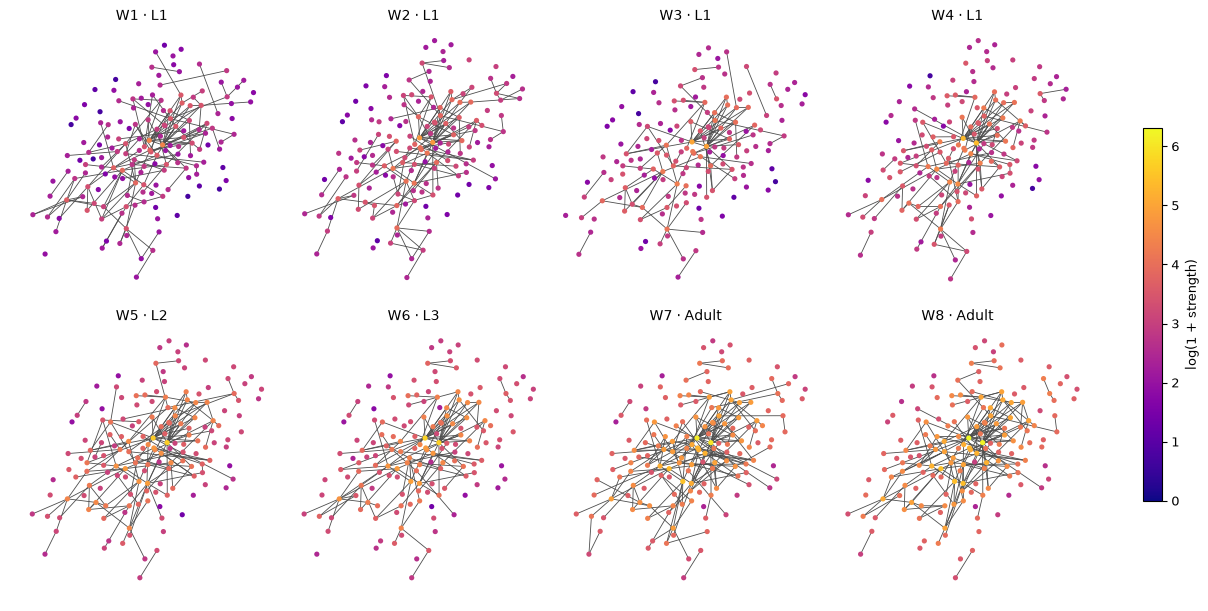

In [6]:
strengths = [
    np.log1p([graph.degree(node, weight="weight") for node in common_nodes])
    for graph in common_graphs
]
maximum_strength = max(values.max() for values in strengths)

fig, axes = plt.subplots(2, 4, figsize=(12, 6), constrained_layout=True)

for number, (graph, values, axis) in enumerate(
    zip(common_graphs, strengths, axes.flat),
    start=1,
):
    edge_weights = np.array(
        [data["weight"] for _, _, data in graph.edges(data=True)]
    )
    cutoff = np.quantile(edge_weights, EDGE_QUANTILE)
    selected_edges = [
        (u, v)
        for u, v, data in graph.edges(data=True)
        if data["weight"] >= cutoff
    ]

    nx.draw_networkx_edges(
        graph,
        common_position,
        edgelist=selected_edges,
        width=0.6,
        edge_color="0.30",
        ax=axis,
    )
    node_plot = nx.draw_networkx_nodes(
        graph,
        common_position,
        nodelist=common_nodes,
        node_color=values,
        node_size=14,
        cmap=CMAP,
        vmin=0,
        vmax=maximum_strength,
        linewidths=0,
        ax=axis,
    )
    axis.set_title(f"W{number} · {STAGES[number - 1]}")
    axis.set_axis_off()

fig.colorbar(
    node_plot,
    ax=axes,
    location="right",
    shrink=0.65,
    label="log(1 + strength)",
)
fig.savefig(FIGURE_DIR / "connectomes.png", dpi=200)
plt.show()

*Figure 1. Developmental connectomes on the 161 shared neurons. Node colour is $c_i^{(r)}=\log(1+s_i^{(r)})$; darker purple indicates lower strength and yellow indicates higher strength. Positions and colour limits are fixed across datasets.*

## Degree distribution

Unweighted degrees from all eight connectomes are pooled. The log-normal fit uses positive values; zero-degree observations remain in the histogram.

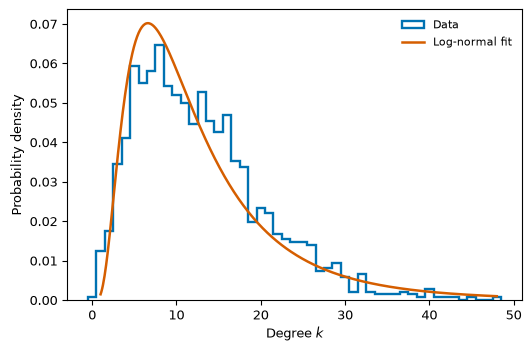

Node observations: 1362
Zero-degree nodes: 1
Log-normal mu: 2.353
Log-normal sigma: 0.681


In [7]:
degrees = pooled_degrees(connectomes)
x, fitted_density, mu, sigma = fit_lognormal(degrees)
bins = np.arange(degrees.max() + 2) - 0.5

fig, axis = plt.subplots(figsize=(5.2, 3.4), constrained_layout=True)
axis.hist(
    degrees,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=1.7,
    color=DATA_COLOUR,
    label="Data",
)
axis.plot(
    x,
    fitted_density,
    color=FIT_COLOUR,
    linewidth=1.8,
    label="Log-normal fit",
)
axis.set(
    xlabel="Degree $k$",
    ylabel="Probability density",
)
axis.legend(frameon=False)
fig.savefig(FIGURE_DIR / "degrees.png", dpi=200)
plt.show()

print(f"Node observations: {len(degrees)}")
print(f"Zero-degree nodes: {(degrees == 0).sum()}")
print(f"Log-normal mu: {mu:.3f}")
print(f"Log-normal sigma: {sigma:.3f}")

*Figure 2. Empirical density of the pooled degrees $k_i^{(r)}$ and the fitted log-normal density $p(k)$. The fit captures the broad right-skewed shape but not every local feature of the histogram.*

## Spectral neighbours

The weighted combinatorial Laplacian is $L^{(r)}=D^{(r)}-W^{(r)}$. The damped-resolvent distance is

$$
d_{\Omega,\eta}^{(r)}(i,j)
=\left[
\sum_{k=2}^{n}
\frac{[\psi_k^{(r)}(i)-\psi_k^{(r)}(j)]^2}
{(\lambda_k^{(r)}-\Omega)^2+\eta^2}
\right]^{1/2}.
$$

The raw weighted spectra shift substantially over development, so low, middle, and high frequencies are selected by spectral quantile within each dataset. The bandwidth is $\eta=0.05\lambda_{\max}$. Each distance matrix is divided by its mean over unordered pairs before cross-stage averaging. This normalization is not part of the distance definition.

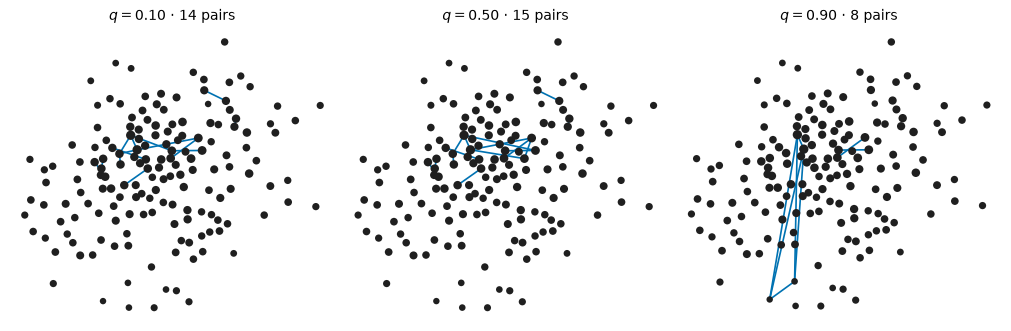

In [8]:
mean_graph, mean_adjacency = average_graph(common_graphs, common_nodes)
mean_position = nx.spring_layout(
    mean_graph,
    weight="weight",
    seed=LAYOUT_SEED,
    iterations=500,
)

mean_strength = mean_adjacency.sum(axis=1)
node_size = 10 + 35 * np.log1p(mean_strength) / np.log1p(mean_strength.max())

spectral_data = [
    graph_eigensystem(graph, common_nodes)
    for graph in common_graphs
]

edge_sets = []
for quantile in SPECTRAL_QUANTILES:
    scaled_distances = []

    for eigenvalues, eigenvectors in spectral_data:
        positive = eigenvalues[eigenvalues > 1e-10]
        omega = np.quantile(positive, quantile)
        eta = ETA_FRACTION * positive[-1]
        distance = spectral_distance(
            eigenvalues,
            eigenvectors,
            omega,
            eta,
        )

        # TODO: revisit this scaling if absolute developmental changes matter.
        pairs = distance[np.triu_indices_from(distance, k=1)]
        scaled_distances.append(distance / pairs.mean())

    mean_distance = np.mean(scaled_distances, axis=0)
    edge_sets.append(
        mutual_neighbours(mean_distance, common_nodes, NEIGHBOUR_COUNT)
    )

fig, axes = plt.subplots(1, 3, figsize=(10, 3.2), constrained_layout=True)
for quantile, edges, axis in zip(SPECTRAL_QUANTILES, edge_sets, axes):
    nx.draw_networkx_edges(
        mean_graph,
        mean_position,
        edgelist=edges,
        width=1.2,
        edge_color=EDGE_COLOUR,
        ax=axis,
    )
    nx.draw_networkx_nodes(
        mean_graph,
        mean_position,
        nodelist=common_nodes,
        node_size=node_size,
        node_color="0.12",
        linewidths=0,
        ax=axis,
    )
    axis.set_title(rf"$q={quantile:.2f}$ · {len(edges)} pairs")
    axis.set_axis_off()

fig.savefig(FIGURE_DIR / "neighbours.png", dpi=200)
plt.show()

*Figure 3. Mutual three-nearest-neighbour pairs after averaging the rescaled distances across datasets. Panels use the 0.10, 0.50, and 0.90 spectral quantiles.*